テストトレインの多様性を増やしたデータセット

In [15]:
# ==========================================================
# タスク2: QM9からデータ取得・train/test分割・保存
# ==========================================================
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

print("QM9データセットをオンラインから取得中...（数秒〜十数秒かかります）")
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/qm9.csv"
N_TRAIN = 15000
N_TEST = 4000
RANDOM_STATE = 42
MIN_SIZE_BASE = 20   # trainを含む全体プールの最低ライン（多様性は保つ）
MIN_SIZE_TEST = 500  # 【変更点】testはこの件数以上の"異性体密集"分子式だけから選ぶ

try:
    df_raw = pd.read_csv(url)
    df = df_raw[['smiles', 'gap']].copy()
    df = df.dropna(subset=['smiles', 'gap'])
    df['gap_eV'] = df['gap'] * 27.2114

    def calc_formula(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return rdMolDescriptors.CalcMolFormula(mol)

    df['formula'] = df['smiles'].apply(calc_formula)
    df = df.dropna(subset=['formula'])

    group_sizes = df.groupby('formula').size()

    # 【変更点】trainは広く多様なプール(size>=20)、
    # testはその中でも異性体が特に多い"濃い"分子式(size>=500)だけから抽出。
    # → trainはこれまで通り幅広い分子を学習できるので致命的な偏りにはならない一方、
    #   testだけ「記述子オンリーでは区別しにくいケース」を集中させられる。
    base_pool = df[df['formula'].isin(group_sizes[group_sizes >= MIN_SIZE_BASE].index)]
    heavy_formulas = group_sizes[group_sizes >= MIN_SIZE_TEST].index
    heavy_pool = base_pool[base_pool['formula'].isin(heavy_formulas)]

    df_test = heavy_pool.sample(n=N_TEST, random_state=RANDOM_STATE)
    remaining_pool = base_pool.drop(df_test.index)  # testで使った分子はtrainから除外(リーク防止)
    df_train = remaining_pool.sample(n=N_TRAIN, random_state=RANDOM_STATE)

    print(f"base_pool: {len(base_pool)} 件 (formula数 {base_pool['formula'].nunique()})")
    print(f"test候補(heavy_pool): {len(heavy_pool)} 件 (formula数 {len(heavy_formulas)})")

    df_train = df_train[['smiles', 'gap_eV']].reset_index(drop=True)
    df_test = df_test[['smiles', 'gap_eV']].reset_index(drop=True)
except Exception as e:
    print(f"エラーが発生しました: {e}")
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()

print("\n【分割完了】")
print(f"train: {len(df_train)} 件 / test: {len(df_test)} 件")
print("\n--- train（上から3件） ---")
print(df_train.head(3))
print("\n--- test（上から3件） ---")
print(df_test.head(3))

os.makedirs("put_csv", exist_ok=True)
df_train.to_csv("diversity/qm9_homo_lumo_train.csv", index=False, encoding="utf-8-sig")
df_test.to_csv("diversity/qm9_homo_lumo_test.csv", index=False, encoding="utf-8-sig")
print("\n保存しました: put_csv/qm9_homo_lumo_train.csv / put_csv/qm9_homo_lumo_test.csv")

QM9データセットをオンラインから取得中...（数秒〜十数秒かかります）
base_pool: 132100 件 (formula数 278)
test候補(heavy_pool): 107267 件 (formula数 60)

【分割完了】
train: 15000 件 / test: 4000 件

--- train（上から3件） ---
               smiles    gap_eV
0    C#CC1(CNC1=O)C#C  7.094012
1       CC1CC=CCOC=N1  6.854552
2  CC1=C2CCC3C(C1)C23  5.839566

--- test（上から3件） ---
              smiles    gap_eV
0  CC1(CN1)C(C#C)C#N  7.559327
1  C1CC11C2OC2C11CO1  8.789282
2    OC1CC1C1CC(O)C1  8.868195

保存しました: put_csv/qm9_homo_lumo_train.csv / put_csv/qm9_homo_lumo_test.csv


In [ ]:
import pandas as pd

df_test = pd.read_csv("diversity/qm9_bandgap_test_with_answer.csv")

# gap_eV列を削除
df_test_no_label = df_test.drop(columns=["gap_eV"])

df_test_no_label.to_csv("diversity/qm9_bandgap_test_without_answer.csv", index=False, encoding="utf-8-sig")

print(df_test_no_label.head(3))

              smiles
0  CC1(CN1)C(C#C)C#N
1  C1CC11C2OC2C11CO1
2    OC1CC1C1CC(O)C1


train: 15000件 / test: 4000件

--- gap_eV 基本統計量 ---
              train         test
count  15000.000000  4000.000000
mean       6.823883     6.863162
std        1.288640     1.220739
min        1.774183     3.025908
25%        5.885826     5.932085
50%        6.781081     6.830061
75%        7.834162     7.831441
max       10.718570    10.092708

train 標準偏差: 1.2886
test  標準偏差: 1.2207


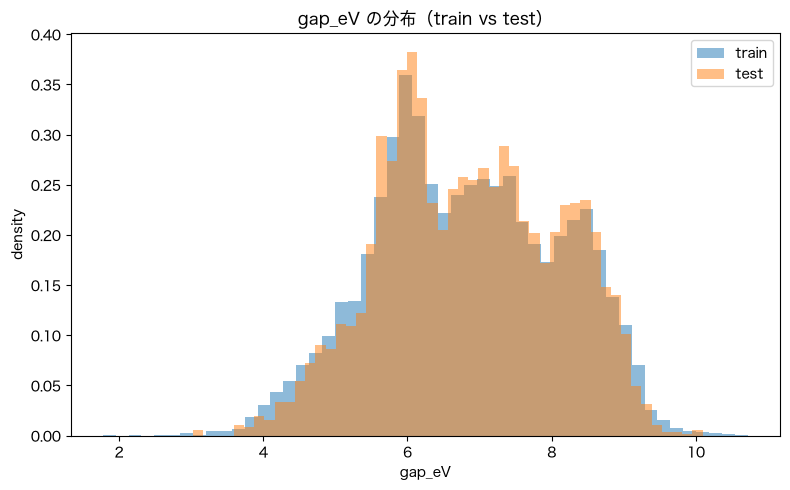


trainのgap_eV範囲: [1.7742, 10.7186]
testのうち範囲外データ数: 0 / 4000 件 (0.00%)

--- 範囲外データ一覧 ---
Empty DataFrame
Columns: [smiles, gap_eV, out_of_range]
Index: []


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ファイル読み込み
df_train = pd.read_csv("diversity/qm9_homo_lumo_train.csv")
df_test = pd.read_csv("diversity/qm9_homo_lumo_test.csv")

print(f"train: {len(df_train)}件 / test: {len(df_test)}件")

# --- 基本統計量（ばらつき） ---
print("\n--- gap_eV 基本統計量 ---")
stats = pd.DataFrame({
    "train": df_train["gap_eV"].describe(),
    "test": df_test["gap_eV"].describe(),
})
print(stats)
print(f"\ntrain 標準偏差: {df_train['gap_eV'].std():.4f}")
print(f"test  標準偏差: {df_test['gap_eV'].std():.4f}")

# --- ヒストグラム ---
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.figure(figsize=(8, 5))
plt.hist(df_train["gap_eV"], bins=50, alpha=0.5, label="train", density=True)
plt.hist(df_test["gap_eV"], bins=50, alpha=0.5, label="test", density=True)
plt.xlabel("gap_eV")
plt.ylabel("density")
plt.title("gap_eV の分布（train vs test）")
plt.legend()
plt.tight_layout()
plt.savefig("gap_eV_histogram.png", dpi=150)
plt.show()

# --- 範囲外（AD外）判定 ---
# 注: これはgap_eVの値だけを見た簡易チェック。
# 本来のAD判定は分子記述子（構造）空間ベースで行うのが望ましい点に注意。
train_min = df_train["gap_eV"].min()
train_max = df_train["gap_eV"].max()
print(f"\ntrainのgap_eV範囲: [{train_min:.4f}, {train_max:.4f}]")

df_test["out_of_range"] = (df_test["gap_eV"] < train_min) | (df_test["gap_eV"] > train_max)
n_out = df_test["out_of_range"].sum()
print(f"testのうち範囲外データ数: {n_out} / {len(df_test)} 件 ({n_out/len(df_test)*100:.2f}%)")

print("\n--- 範囲外データ一覧 ---")
print(df_test[df_test["out_of_range"]])

# df_test.to_csv(qm9_homo_lumo_test_with_flag.csv", index=False, encoding="utf-8-sig")

In [1]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("for_M1/submission.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("diversity/qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# MAE計算
mae = mean_absolute_error(merged["gap_eV_true"], merged["gap_eV_pred"])
print(f"MAE: {mae:.5f} eV")

MAE: 0.19090 eV
